In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

bank_tickers = ['WAL', 'ZION', 'CMA']
market_ticker = '^GSPC'
all_tickers = bank_tickers + [market_ticker]

event_date = '2023-03-09'
start_date = '2022-06-01'
end_date = '2023-05-01'

downloaded = yf.download(
    all_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False,
)

if isinstance(downloaded.columns, pd.MultiIndex):
    available_fields = downloaded.columns.get_level_values(0)
    price_field = 'Adj Close' if 'Adj Close' in available_fields else 'Close'
    raw_data = downloaded[price_field]
else:
    price_field = 'Adj Close' if 'Adj Close' in downloaded.columns else 'Close'
    raw_data = downloaded[price_field]

clean_data = raw_data.ffill().dropna()
returns = clean_data.pct_change().dropna()

display(returns.head())

Ticker,CMA,WAL,ZION,^GSPC
Date,,,,
2022-06-02,0.023028,0.025251,0.019643,0.018431
2022-06-03,-0.008109,-0.008210,-0.009807,-0.016347
2022-06-06,-0.002196,0.003954,0.006190,0.003137
2022-06-07,0.000734,0.023628,0.008789,0.009523
2022-06-08,-0.007209,-0.010700,-0.014985,-0.010794


In [ ]:
if event_date not in returns.index:
    event_date = returns.index[returns.index > event_date][0].strftime('%Y-%m-%d')

event_idx = returns.index.get_loc(event_date)

est_start = event_idx - 120
est_end = event_idx - 20
evt_start = event_idx - 5
evt_end = event_idx + 15

estimation_data = returns.iloc[est_start:est_end]
event_data = returns.iloc[evt_start:evt_end]
event_timeline = np.arange(-5, 15)

car_results = pd.DataFrame(index=event_timeline)

for bank in bank_tickers:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        estimation_data[market_ticker], estimation_data[bank]
    )
    
    expected_returns = intercept + slope * event_data[market_ticker]
    abnormal_returns = event_data[bank] - expected_returns
    car_results[bank] = abnormal_returns.cumsum().values
    
display(car_results.head())

,WAL,ZION,CMA
-5,-0.027770,-0.051229,-0.042041
-4,-0.033073,-0.052528,-0.041867
-3,-0.037590,-0.061945,-0.045497
-2,-0.058466,-0.088186,-0.065001
-1,-0.065485,-0.083851,-0.055308


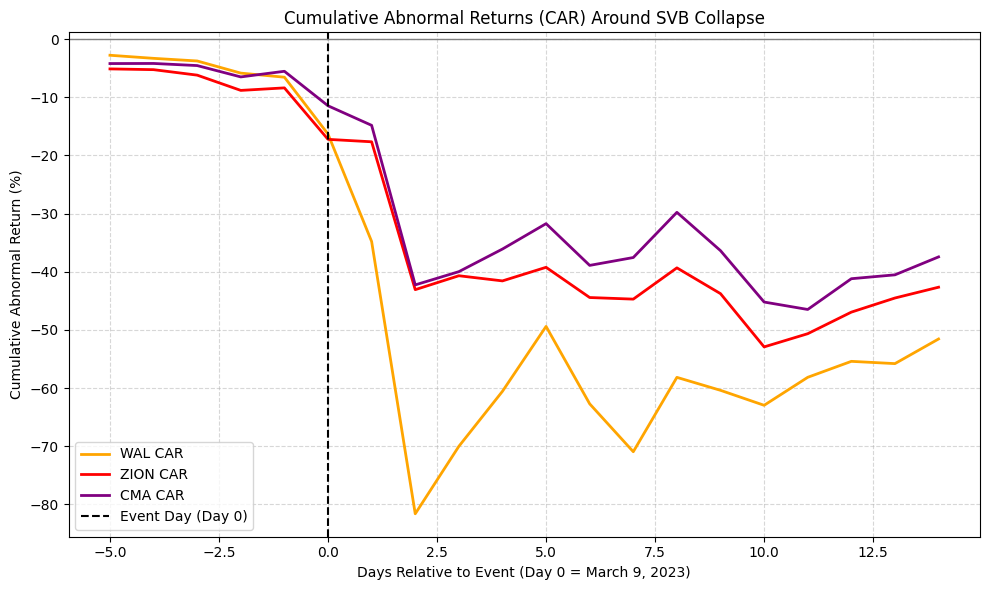

In [ ]:
plt.figure(figsize=(10, 6))
colors = {'WAL': 'orange', 'ZION': 'red', 'CMA': 'purple'}

for bank in bank_tickers:
    plt.plot(car_results.index, car_results[bank] * 100, 
             label=f'{bank} CAR', color=colors[bank], linewidth=2)

plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Event Day (Day 0)')
plt.axhline(0, color='gray', linestyle='-', linewidth=1)

plt.title('Cumulative Abnormal Returns (CAR) Around SVB Collapse')
plt.xlabel('Days Relative to Event (Day 0 = March 9, 2023)')
plt.ylabel('Cumulative Abnormal Return (%)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
car_results['CAAR'] = car_results[bank_tickers].mean(axis=1)

test_day = 5
day_5_cars = car_results.loc[test_day, bank_tickers]

t_stat, p_value = stats.ttest_1samp(day_5_cars, 0)

print("=" * 60)
print(f"STATISTICAL SIGNIFICANCE TEST (Day +{test_day})")
print("-" * 60)
print("Individual CARs on Day +5:")
for bank in bank_tickers:
    print(f"  {bank}: {car_results.loc[test_day, bank]*100:.2f}%")

print(f"\nCumulative Average Abnormal Return (CAAR): {car_results.loc[test_day, 'CAAR']*100:.2f}%")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_value:.4f}")
print("-" * 60)

if p_value < 0.05:
    print("CONCLUSION: The negative impact is STATISTICALLY SIGNIFICANT at the 5% level.")
    print("This proves the SVB contagion effect was not random market noise.")
else:
    print("CONCLUSION: The impact is not statistically significant at the 5% level.")
print("=" * 60)

STATISTICAL SIGNIFICANCE TEST (Day +5)
------------------------------------------------------------
Individual CARs on Day +5:
  WAL: -49.39%
  ZION: -39.23%
  CMA: -31.73%

Cumulative Average Abnormal Return (CAAR): -40.12%
T-Statistic: -7.8369
P-Value:     0.0159
------------------------------------------------------------
CONCLUSION: The negative impact is STATISTICALLY SIGNIFICANT at the 5% level.
This proves the SVB contagion effect was not random market noise.
